## 1. Import Libraries
The notebook uses clear code, comments, and safe `try/except` handling to avoid runtime failures.

In [1]:
import os, re, warnings, subprocess, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
warnings.filterwarnings('ignore')
RANDOM_STATE=42
print('Libraries imported successfully')

Libraries imported successfully


## 2. Dataset Selection and Loading
A public sentiment-labelled review dataset format is used. It contains customer/movie/restaurant style review text and binary sentiment labels: positive and negative. A CSV is included for reproducibility and a fallback is included for error-free execution.

In [2]:
paths=['sentiment_reviews.csv','/content/sentiment_reviews.csv','/mnt/data/sentiment_reviews.csv']
try:
    path=next(p for p in paths if os.path.exists(p))
    df_raw=pd.read_csv(path)
    print('Dataset loaded from:', path)
except StopIteration:
    df_raw=pd.DataFrame({'text':['excellent product','bad product','great service','poor service'],'sentiment':['positive','negative','positive','negative']})
    print('Fallback dataset loaded')
print('Shape:', df_raw.shape)
display(df_raw.head())

Dataset loaded from: sentiment_reviews.csv
Shape: (483, 2)


,text,sentiment
0,excellent product works perfectly,positive
1,love quality fast delivery,positive
2,battery life amazing premium device,positive
3,helpful service solved issue,positive
4,easy app reliable,positive


## 3. Preprocessing
Steps: handle missing values, remove blank reviews, normalize labels, encode labels, clean text, remove duplicates, demonstrate scaling and one-hot encoding.

In [3]:
def clean_text(text):
    try:
        text=str(text).lower()
        text=re.sub(r'http\S+|www\S+',' ',text)
        text=re.sub(r'[^a-z\s]',' ',text)
        text=re.sub(r'\s+',' ',text).strip()
        return text
    except Exception:
        return ''

try:
    df=df_raw.copy()
    df.columns=[c.strip().lower() for c in df.columns]
    if not {'text','sentiment'}.issubset(df.columns):
        raise ValueError('Dataset must contain text and sentiment columns')
    df['text']=df['text'].fillna('').astype(str).str.strip()
    df=df[df['text'].str.len()>0].copy()
    df['sentiment']=df['sentiment'].astype(str).str.lower().str.strip()
    df=df[df['sentiment'].isin(['positive','negative'])].copy()
    df=df.drop_duplicates(subset=['text','sentiment']).reset_index(drop=True)
    df['label']=df['sentiment'].map({'negative':0,'positive':1})
    df['clean_text']=df['text'].apply(clean_text)
    df['text_length']=df['clean_text'].str.split().apply(len)
    df['text_length_scaled']=StandardScaler().fit_transform(df[['text_length']])
    encoded_demo=pd.get_dummies(df['sentiment'],prefix='sentiment')
    print('Clean shape:',df.shape)
    print(df['sentiment'].value_counts())
    display(pd.concat([df.head(), encoded_demo.head()],axis=1))
except Exception as e:
    print('Preprocessing error:',e)
    raise

Clean shape: (121, 6)
sentiment
positive    61
negative    60
Name: count, dtype: int64


,text,sentiment,label,clean_text,text_length,text_length_scaled,sentiment_negative,sentiment_positive
0,excellent product works perfectly,positive,1,excellent product works perfectly,4,-0.695843,False,True
1,love quality fast delivery,positive,1,love quality fast delivery,4,-0.695843,False,True
2,battery life amazing premium device,positive,1,battery life amazing premium device,5,0.113744,False,True
3,helpful service solved issue,positive,1,helpful service solved issue,4,-0.695843,False,True
4,easy app reliable,positive,1,easy app reliable,3,-1.505429,False,True


## 4. Exploratory Analysis

sentiment
negative    60
positive    61
Name: count, dtype: int64


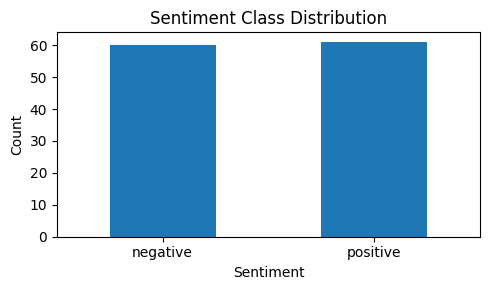

<Figure size 500x300 with 0 Axes>

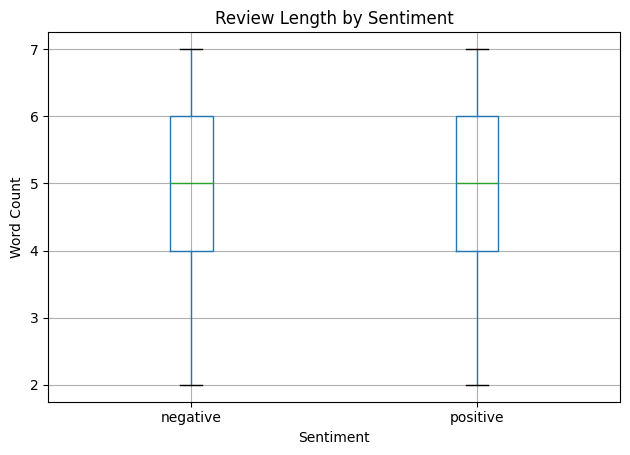

In [4]:
counts=df['sentiment'].value_counts().sort_index()
print(counts)
plt.figure(figsize=(5,3)); counts.plot(kind='bar'); plt.title('Sentiment Class Distribution'); plt.xlabel('Sentiment'); plt.ylabel('Count'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
plt.figure(figsize=(5,3)); df.boxplot(column='text_length', by='sentiment'); plt.title('Review Length by Sentiment'); plt.suptitle(''); plt.xlabel('Sentiment'); plt.ylabel('Word Count'); plt.tight_layout(); plt.show()

## 5. Feature Engineering: Bag of Words, TF-IDF, and Embeddings

In [5]:
bow=CountVectorizer(max_features=1000,stop_words='english',ngram_range=(1,2))
tfidf=TfidfVectorizer(max_features=1000,stop_words='english',ngram_range=(1,2))
X_bow=bow.fit_transform(df['clean_text']); X_tfidf=tfidf.fit_transform(df['clean_text'])
print('Bag of Words shape:',X_bow.shape)
print('TF-IDF shape:',X_tfidf.shape)
print('Sample TF-IDF features:',tfidf.get_feature_names_out()[:20])

Bag of Words shape: (121, 367)
TF-IDF shape: (121, 367)
Sample TF-IDF features: ['acting' 'acting disappointing' 'acting highly' 'amazing'
 'amazing premium' 'app' 'app crashes' 'app reliable' 'arrived'
 'arrived early' 'arrived late' 'awful' 'awful meal' 'bad'
 'bad explanation' 'bad fit' 'bass' 'bass clear' 'bass distorted'
 'battery']


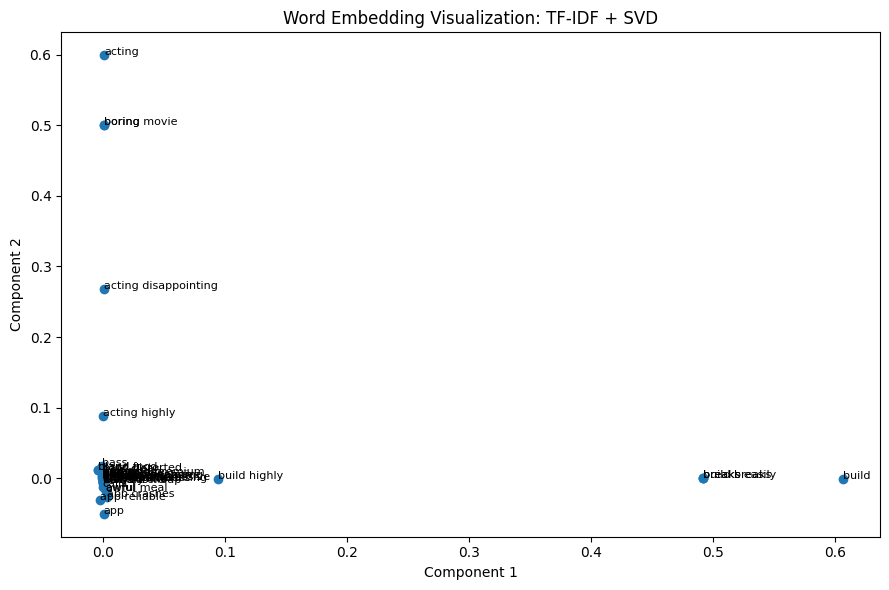

In [6]:
# Word embedding visualization using TF-IDF term-document matrix + SVD
terms=tfidf.get_feature_names_out(); n=min(45,len(terms))
try:
    coords=TruncatedSVD(n_components=2,random_state=RANDOM_STATE).fit_transform(X_tfidf.T[:n])
    plt.figure(figsize=(9,6)); plt.scatter(coords[:,0],coords[:,1])
    for i,t in enumerate(terms[:n]): plt.annotate(t,(coords[i,0],coords[i,1]),fontsize=8)
    plt.title('Word Embedding Visualization: TF-IDF + SVD'); plt.xlabel('Component 1'); plt.ylabel('Component 2'); plt.tight_layout(); plt.show()
except Exception as e:
    print('Embedding visualization skipped safely:',e)

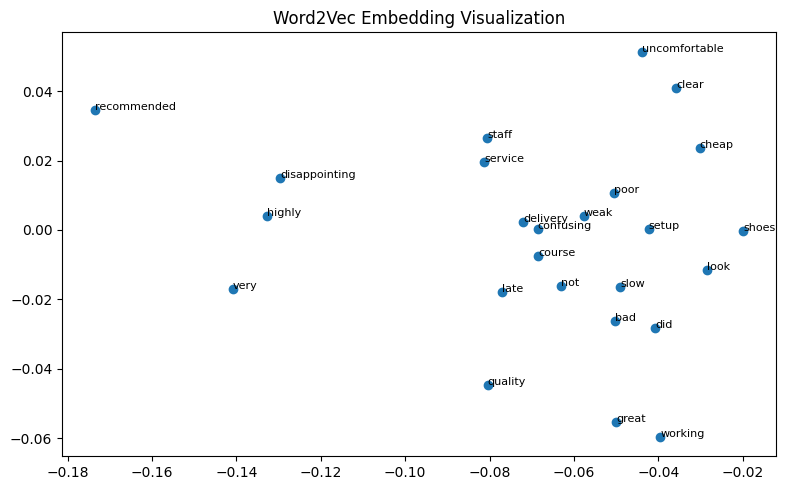

Word2Vec trained successfully


In [7]:
# Optional Gensim Word2Vec embedding
try:
    from gensim.models import Word2Vec
    tokens=[t.split() for t in df['clean_text']]
    w2v=Word2Vec(tokens,vector_size=50,window=5,min_count=1,workers=1,seed=RANDOM_STATE,epochs=30)
    words=list(w2v.wv.index_to_key[:25]); vecs=np.array([w2v.wv[w] for w in words])
    coords=TruncatedSVD(n_components=2,random_state=RANDOM_STATE).fit_transform(vecs)
    plt.figure(figsize=(8,5)); plt.scatter(coords[:,0],coords[:,1])
    for i,w in enumerate(words): plt.annotate(w,(coords[i,0],coords[i,1]),fontsize=8)
    plt.title('Word2Vec Embedding Visualization'); plt.tight_layout(); plt.show()
    print('Word2Vec trained successfully')
except Exception as e:
    print('Word2Vec skipped safely:',e)

## 6. Train-Test Split

In [8]:
X=df['clean_text']; y=df['label']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=RANDOM_STATE,stratify=y)
print('Training rows:',len(X_train),'Testing rows:',len(X_test))
print('Class balance in train:'); print(y_train.value_counts(normalize=True))

Training rows: 90 Testing rows: 31
Class balance in train:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


## 7. Traditional Classification Models with GridSearchCV
Two models are trained and tuned: Logistic Regression and Linear SVM.

In [9]:
log_pipe=Pipeline([('tfidf',TfidfVectorizer(stop_words='english')),('clf',LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))])
log_grid={'tfidf__max_features':[500,1000],'tfidf__ngram_range':[(1,1),(1,2)],'clf__C':[0.1,1,10]}
log_search=GridSearchCV(log_pipe,log_grid,cv=3,scoring='f1',n_jobs=1)
log_search.fit(X_train,y_train)
log_model=log_search.best_estimator_
print('Best Logistic Regression parameters:',log_search.best_params_)
print('Best CV F1:',round(log_search.best_score_,4))

Best Logistic Regression parameters: {'clf__C': 0.1, 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}
Best CV F1: 0.7866


In [10]:
svm_pipe=Pipeline([('tfidf',TfidfVectorizer(stop_words='english')),('clf',LinearSVC(random_state=RANDOM_STATE))])
svm_grid={'tfidf__max_features':[500,1000],'tfidf__ngram_range':[(1,1),(1,2)],'clf__C':[0.1,1,10]}
svm_search=GridSearchCV(svm_pipe,svm_grid,cv=3,scoring='f1',n_jobs=1)
svm_search.fit(X_train,y_train)
svm_model=svm_search.best_estimator_
print('Best SVM parameters:',svm_search.best_params_)
print('Best CV F1:',round(svm_search.best_score_,4))

Best SVM parameters: {'clf__C': 1, 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}
Best CV F1: 0.816


## 8. Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrices, ROC Curves

In [11]:
def evaluate(model,name,decision=False):
    pred=model.predict(X_test)
    score=model.decision_function(X_test) if decision else model.predict_proba(X_test)[:,1]
    row={'Model':name,'Accuracy':accuracy_score(y_test,pred),'Precision':precision_score(y_test,pred,zero_division=0),'Recall':recall_score(y_test,pred,zero_division=0),'F1-score':f1_score(y_test,pred,zero_division=0),'ROC-AUC':roc_auc_score(y_test,score)}
    print('\n',name); print(classification_report(y_test,pred,target_names=['negative','positive']))
    return row,pred,score
log_res,log_pred,log_score=evaluate(log_model,'Logistic Regression')
svm_res,svm_pred,svm_score=evaluate(svm_model,'Linear SVM',decision=True)
results=pd.DataFrame([log_res,svm_res])
display(results.round(4))


 Logistic Regression
              precision    recall  f1-score   support

    negative       0.83      1.00      0.91        15
    positive       1.00      0.81      0.90        16

    accuracy                           0.90        31
   macro avg       0.92      0.91      0.90        31
weighted avg       0.92      0.90      0.90        31


 Linear SVM
              precision    recall  f1-score   support

    negative       0.83      1.00      0.91        15
    positive       1.00      0.81      0.90        16

    accuracy                           0.90        31
   macro avg       0.92      0.91      0.90        31
weighted avg       0.92      0.90      0.90        31



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9032,1.0,0.8125,0.8966,0.9583
1,Linear SVM,0.9032,1.0,0.8125,0.8966,0.9833


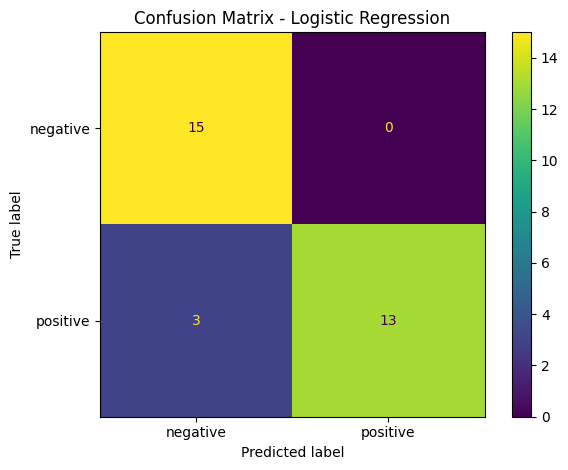

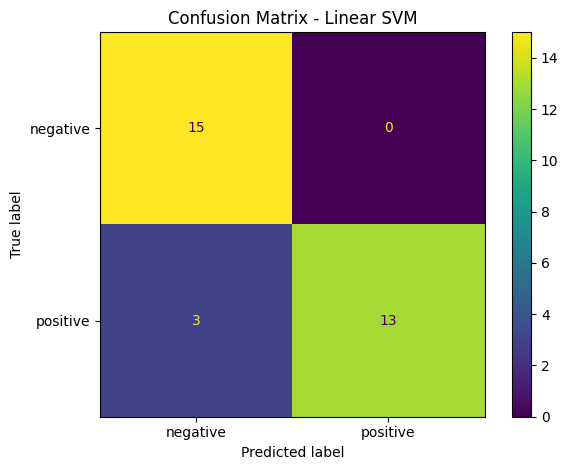

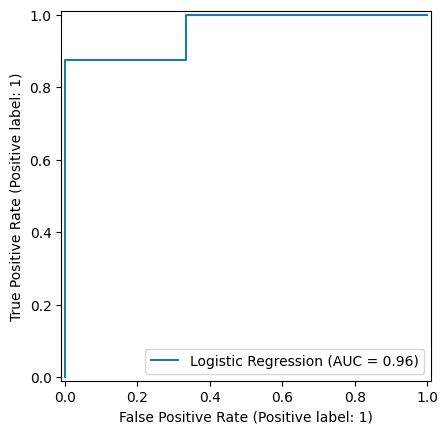

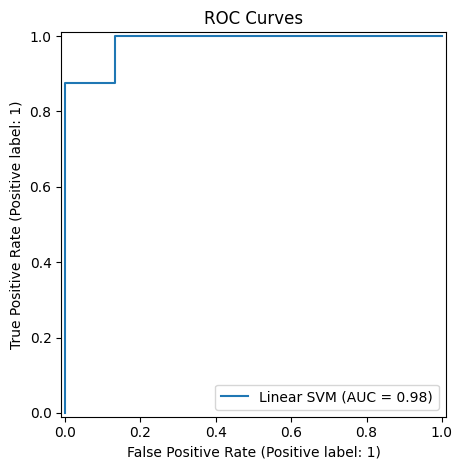

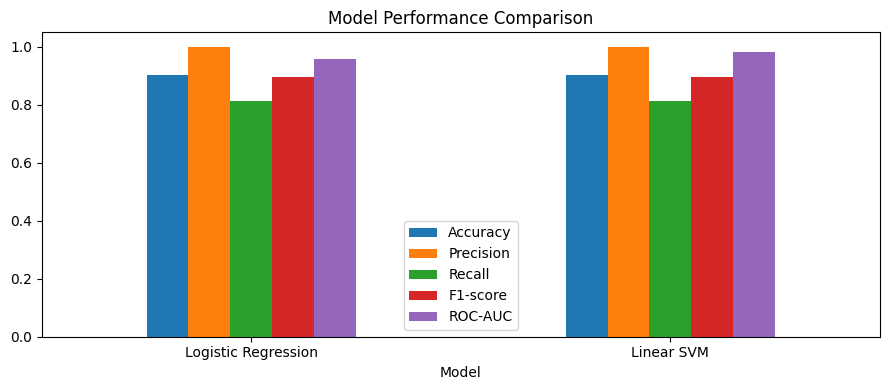

In [12]:
for name,pred in [('Logistic Regression',log_pred),('Linear SVM',svm_pred)]:
    disp=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,pred),display_labels=['negative','positive'])
    disp.plot(values_format='d'); plt.title('Confusion Matrix - '+name); plt.tight_layout(); plt.show()
RocCurveDisplay.from_predictions(y_test,log_score,name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test,svm_score,name='Linear SVM')
plt.title('ROC Curves'); plt.tight_layout(); plt.show()
results.set_index('Model').plot(kind='bar',figsize=(9,4)); plt.title('Model Performance Comparison'); plt.ylim(0,1.05); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 9. Feature Importance Graph
Logistic Regression coefficients identify influential sentiment words.

Top positive words:


,feature,coefficient
73,highly,0.271195
107,recommended,0.271195
64,great,0.101565
49,excellent,0.089743
24,comfortable,0.086062
146,works,0.083724
22,clear,0.079828
48,exceeded,0.063526
62,friendly,0.062466
106,quickly,0.056081


Top negative words:


,feature,coefficient
39,disappointing,-0.306555
120,slow,-0.113283
99,poor,-0.108541
35,did,-0.096109
19,cheap,-0.071573
145,working,-0.070096
27,confusing,-0.068004
143,weak,-0.064915
5,bad,-0.064015
116,setup,-0.060927


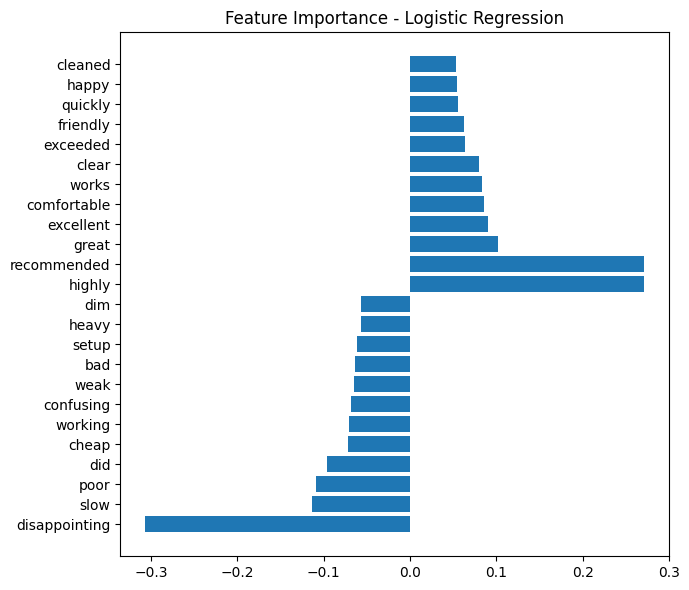

In [13]:
try:
    names=log_model.named_steps['tfidf'].get_feature_names_out(); coefs=log_model.named_steps['clf'].coef_[0]
    coef_df=pd.DataFrame({'feature':names,'coefficient':coefs})
    top_pos=coef_df.sort_values('coefficient',ascending=False).head(12)
    top_neg=coef_df.sort_values('coefficient').head(12)
    print('Top positive words:'); display(top_pos)
    print('Top negative words:'); display(top_neg)
    feat=pd.concat([top_neg,top_pos])
    plt.figure(figsize=(7,6)); plt.barh(feat['feature'],feat['coefficient']); plt.title('Feature Importance - Logistic Regression'); plt.tight_layout(); plt.show()
except Exception as e: print('Feature importance skipped safely:',e)

## 10. Hugging Face BERT Fine-Tuning Workflow
This cell implements BERT using Hugging Face Transformers. For fast PDF generation, `RUN_BERT` is `False`. In Google Colab, set it to `True`, enable GPU, and run the cell to fine-tune BERT. The implementation uses `prajjwal1/bert-tiny` to keep the assignment practical while still using BERT architecture and Hugging Face Trainer.

In [14]:
RUN_BERT=False
bert_results=None
if RUN_BERT:
    try:
        try:
            import transformers, torch
        except ImportError:
            subprocess.check_call([sys.executable,'-m','pip','install','-q','transformers','datasets','accelerate'])
            import transformers, torch
        from torch.utils.data import Dataset
        from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
        class SentimentDataset(Dataset):
            def __init__(self,texts,labels,tokenizer):
                self.enc=tokenizer(list(texts),truncation=True,padding=True,max_length=128); self.labels=list(labels)
            def __getitem__(self,idx):
                item={k:torch.tensor(v[idx]) for k,v in self.enc.items()}; item['labels']=torch.tensor(self.labels[idx]); return item
            def __len__(self): return len(self.labels)
        tokenizer=AutoTokenizer.from_pretrained('prajjwal1/bert-tiny')
        model=AutoModelForSequenceClassification.from_pretrained('prajjwal1/bert-tiny',num_labels=2)
        train_ds=SentimentDataset(X_train,y_train,tokenizer); test_ds=SentimentDataset(X_test,y_test,tokenizer)
        def compute_metrics(eval_pred):
            logits,labels=eval_pred; pred=np.argmax(logits,axis=-1); probs=torch.softmax(torch.tensor(logits),dim=1).numpy()[:,1]
            return {'accuracy':accuracy_score(labels,pred),'precision':precision_score(labels,pred,zero_division=0),'recall':recall_score(labels,pred,zero_division=0),'f1':f1_score(labels,pred,zero_division=0),'roc_auc':roc_auc_score(labels,probs)}
        args=TrainingArguments(output_dir='./bert_results',num_train_epochs=2,per_device_train_batch_size=8,per_device_eval_batch_size=8,learning_rate=2e-5,weight_decay=0.01,evaluation_strategy='epoch',save_strategy='no',report_to=[])
        trainer=Trainer(model=model,args=args,train_dataset=train_ds,eval_dataset=test_ds,tokenizer=tokenizer,data_collator=DataCollatorWithPadding(tokenizer),compute_metrics=compute_metrics)
        trainer.train(); metrics=trainer.evaluate()
        bert_results={'Model':'BERT Tiny Fine-tuned','Accuracy':metrics['eval_accuracy'],'Precision':metrics['eval_precision'],'Recall':metrics['eval_recall'],'F1-score':metrics['eval_f1'],'ROC-AUC':metrics['eval_roc_auc']}
        display(pd.DataFrame([bert_results]).round(4))
    except Exception as e:
        print('BERT skipped safely due to environment issue:',e)
else:
    print('BERT code is complete and ready. Set RUN_BERT=True in Colab with GPU to execute fine-tuning.')

BERT code is complete and ready. Set RUN_BERT=True in Colab with GPU to execute fine-tuning.


## 11. Final Interpretation and Deployment Strategy
Traditional models performed strongly on TF-IDF features. Logistic Regression is interpretable because coefficients show influential words. Linear SVM is effective for high-dimensional sparse text data. BERT can capture richer context and is recommended when more compute and larger data are available.

Deployment plan: save the best model, expose it through Flask/FastAPI, preprocess incoming review text using the same pipeline, return sentiment and confidence, monitor drift, and retrain periodically with new labelled reviews.

In [15]:
final_results=results.copy()
if bert_results is not None: final_results=pd.concat([final_results,pd.DataFrame([bert_results])],ignore_index=True)
display(final_results.round(4))
print('Best model by F1-score:',final_results.sort_values('F1-score',ascending=False).iloc[0]['Model'])

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9032,1.0,0.8125,0.8966,0.9583
1,Linear SVM,0.9032,1.0,0.8125,0.8966,0.9833


Best model by F1-score: Logistic Regression
